# Toric code NES test

This notebook tests the sampled NES implementation on the 2D toric code. The toric code lives on **edges**, so `shape=(Lx,Ly)` means `N_edges=2*Lx*Ly` spin variables. On a torus, the ground state is four-fold degenerate.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Desktop" / "Master Thesis" / "nes_lattice_project"
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.hamiltonians import make_hamiltonian_spec
from nes_lattice.references import get_reference_energies
from nes_lattice.plots import plot_history, plot_diagnostics, print_final

PROJECT_ROOT


PosixPath('/home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project')

## Check toric-code terms and exact ground degeneracy

In [3]:
hspec = make_hamiltonian_spec(name='toric_code', shape=(2, 2), Je=1.0, Jm=1.0, pbc=True)
terms = hspec.bonds_np
stars, plaquettes = terms[0], terms[1]
print('shape:', hspec.shape)
print('edge spins N:', hspec.N)
print('number of stars:', len(stars))
print('number of plaquettes:', len(plaquettes))
print('first star:', stars[0])
print('first plaquette:', plaquettes[0])

ref, msg = get_reference_energies(hspec, k=4, prefer='auto')
print('reference source:', msg)
print('first 4 reference energies:', ref)


shape: (2, 2)
edge spins N: 8
number of stars: 4
number of plaquettes: 4
first star: [0 4 1 3]
first plaquette: [0 5 2 1]
reference source: toric_code_exact_4fold_ground_degeneracy
first 4 reference energies: [-8. -8. -8. -8.]


## Example A: 2x2 toric code, k=4, FFN

This is the first correctness test. Since `N_edges=8`, exact span evaluation and dense ED are cheap. The target is four energies close to `-8` for `Je=Jm=1`.


In [8]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian='toric_code',
    k=4,
    Je=1.0,
    Jm=1.0,
    model='ffn',
    hidden=(64, 64),
    steps=10000,
    lr=2e-3,
    n_chains=96,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    reference='auto',
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_ffn.json'
save_history(history, save_path, cfg)

print('saved to:', save_path)


{'step': 0, 'loss_sum': -4.1198564712641845, 'train_energy_estimator': nan, 'energies': [-4.002946346095682, -0.11948830683960185, -0.001072112516985249, 0.003650294188085364], 'reference': [-8.0, -8.0, -8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [3.9970536539043184, 7.880511693160398, 7.998927887483014, 8.003650294188086], 'trace_error': 27.880143528735815, 'condition_number_S': 425779.7097951964, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 100, 'loss_sum': -3.9975289180631313, 'train_energy_estimator': -3.787461757659912, 'energies': [-3.9999772273830665, -0.0008812306699905654, -0.00037796414414934735, 0.0037075041340754065], 'reference': [-8.0, -8.0, -8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [4.0000227726169335, 7.99911876933001, 7.99962203585585, 8.003707504134075], 'trace_error': 28.002471081936868, 'condition_number_S':

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_2x2_k4_ffn.json
Config:             {'shape': [2, 2], 'hamiltonian': 'toric_code', 'k': 4, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'ffn', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 10000, 'lr': 0.002, 'n_chains': 96, 'n_samples': 8, 'sweep_steps': 8, 'burn_in': 80, 'det_jitter': 1e-08, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-08, 'seed': 0}
Final NES energies: [-7.917294706869604, -7.781123540883972, -3.9646436102125695, -3.948696965406155]
Reference:          [-8.0, -8.0, -8.0, -8.0]
Reference source:   toric_code_exact_4fold_ground_degeneracy
Abs errors:         [0.0827052931303962, 0.218876459

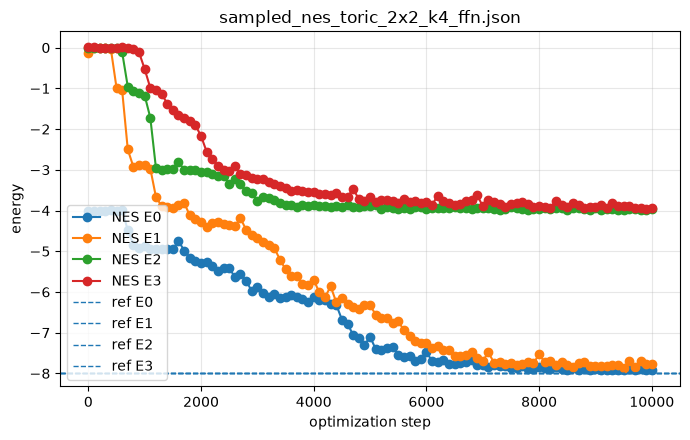

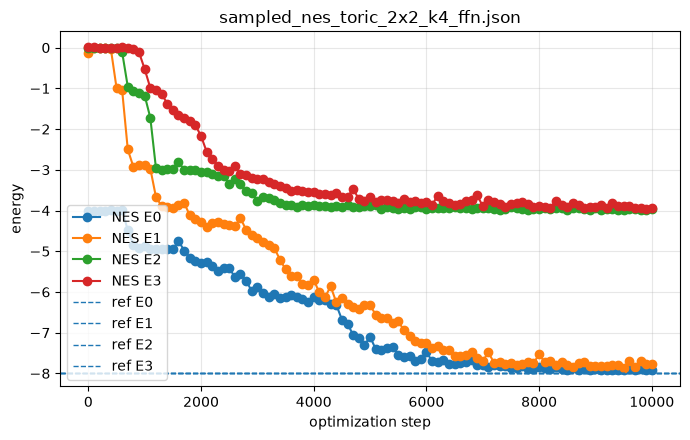

In [ ]:
print_final(save_path)
fig, ax = plot_history(save_path)


In [ ]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond


In [ ]:
fig_diag


## Example B: 3x3 toric code, k=4, CNN

This is closer to the intended 2D usage. `shape=(3,3)` has `N_edges=18`, so exact evaluation over `2^18` configs is skipped by setting `eval_exact_if_sites_leq=12`. The analytic toric-code reference still gives the four degenerate ground energies `E=-18` for `Je=Jm=1`.


In [ ]:
cfg = TrainConfig(
    shape=(3, 3),
    hamiltonian='toric_code',
    k=4,
    Je=1.0,
    Jm=1.0,
    model='cnn',
    channels=(16, 16),
    kernel_size=3,
    steps=2000,
    lr=1e-3,
    n_chains=128,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    eval_chains=128,
    eval_samples=32,
    reference='auto',
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_3x3_k4_cnn.json'
save_history(history, save_path, cfg)

print('saved to:', save_path)


In [ ]:
print_final(save_path)
fig, ax = plot_history(save_path)
fig


In [ ]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond


In [ ]:
fig_diag
